# DCT Laboratory — Volume II, Chapter 11
## Distributionally Robust Enterprise Optimization
**Seed `26211`** · Companion to the chapter and AXIOM Module **AXIOM-11 (Vol. II)**

Ambiguity with teeth — and everything in closed form. The **worst case over a
total-variation ball**: mass slides from the best outcome to the worst,
piecewise-linearly, kinking at $\delta = 0.4$. The **decision flip**: nominal
analysis picks bold project B (6.8 vs 4.8); DRO at $\delta = 0.15$ picks safe
A (4.5 vs 4.1), with the flip at exactly $\delta^* = 0.125$. And the
**data-driven radius** $\delta_n = 0.55/\sqrt{n}$: twenty samples buy back
the bold choice. Mirrored in `DCT_V2_Ch11_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26211
Z = np.array([10.0, 6.0, 2.0, -4.0]); PHAT = np.array([0.4, 0.3, 0.2, 0.1])
def wc_mean(z, phat, delta):
    """Worst-case E[z] over the TV ball {p : ||p - phat||_TV <= delta} (minimizing adversary):
    slide mass from highest-z outcomes to the lowest-z outcome."""
    p = phat.astype(float).copy()
    order = np.argsort(z)[::-1]           # highest payoff first
    lo = int(np.argmin(z)); budget = delta
    for i in order:
        if i == lo or budget <= 0: continue
        take = min(p[i], budget)
        p[i] -= take; p[lo] += take; budget -= take
    return float(p @ z)
# Panel 2: two projects on the same support probabilities
ZA = np.array([5.0, 5.0, 5.0, 3.0]); ZB = np.array([12.0, 8.0, 1.0, -6.0])
def flip_delta():
    # wc_A = 4.8 - 2d ; wc_B = 6.8 - 18d ; equal at d = 2/16
    return 2.0/16.0
# Panel 3: data-driven radius
def delta_n(n): return 0.55/np.sqrt(n)
def choice(n):
    d = delta_n(n)
    return "B" if wc_mean(ZB, PHAT, d) > wc_mean(ZA, PHAT, d) else "A"
def n_switch():
    n = 1
    while choice(n) == "A": n += 1
    return n

def reference_values():
    return {
        "nominal_mean": round(float(PHAT @ Z),4),
        "wc_mean_d01": round(wc_mean(Z, PHAT, 0.10),4),
        "wc_slope": round((float(PHAT@Z)-wc_mean(Z,PHAT,0.10))/0.10,4),
        "kink_delta": 0.4,
        "wc_mean_d05": round(wc_mean(Z, PHAT, 0.50),4),
        "nom_A": round(float(PHAT @ ZA),4), "nom_B": round(float(PHAT @ ZB),4),
        "wc_A_015": round(wc_mean(ZA, PHAT, 0.15),4),
        "wc_B_015": round(wc_mean(ZB, PHAT, 0.15),4),
        "dro_flip_delta": round(flip_delta(),4),
        "delta_n20": round(delta_n(20),4),
        "n_switch": n_switch(),
        "delta_n100": round(delta_n(100),4),
        "wc_B_n100": round(wc_mean(ZB, PHAT, delta_n(100)),4),
    }
if __name__ == "__main__":
    [print(f"{k:16s} {v}") for k,v in reference_values().items()]

nominal_mean     5.8
wc_mean_d01      4.4
wc_slope         14.0
kink_delta       0.4
wc_mean_d05      -0.8
nom_A            4.8
nom_B            6.8
wc_A_015         4.5
wc_B_015         4.1
dro_flip_delta   0.125
delta_n20        0.123
n_switch         20
delta_n100       0.055
wc_B_n100        5.81


## Panel 1 — The worst-case distribution is extremal
Support $z = (10, 6, 2, -4)$, nominal $\hat{p} = (0.4, 0.3, 0.2, 0.1)$,
ambiguity = the TV ball of radius $\delta$ around $\hat{p}$. The adversary's
optimal move (Worst-Case Distribution Existence Theorem) is boundary-simple:
slide mass $\delta$ from the *highest* payoff to the *lowest*. So the
worst-case mean falls **linearly at slope $z_{max} - z_{min} = 14$** until the
best outcome's mass is exhausted at $\delta = 0.4$ — then the slope kinks to
the next spread. Ambiguity Sets Capture Distributional Uncertainty (Prop.),
priced: each unit of radius costs 14 units of guaranteed mean.

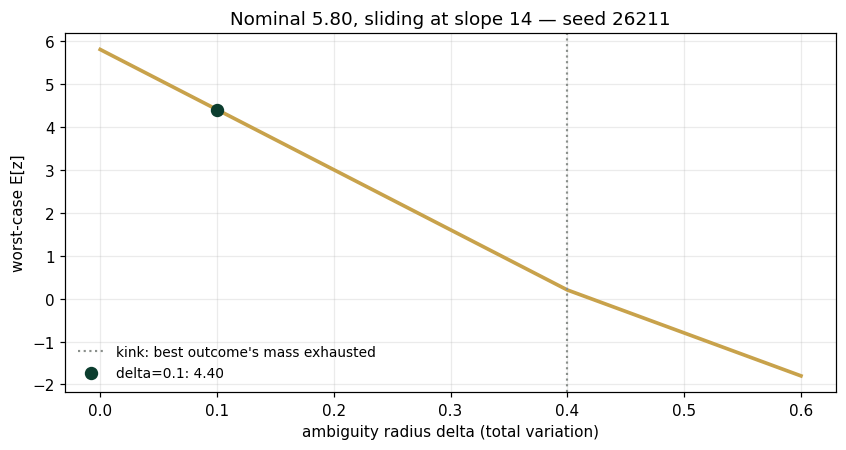

nominal 5.8000   wc(0.1) = 4.4000   wc(0.5) = -0.8000


In [2]:
ds = np.linspace(0, 0.6, 121)
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ds, [wc_mean(Z, PHAT, d) for d in ds], c="#C8A24B", lw=2.4)
ax.axvline(0.4, c="#8A8F8B", ls=":", lw=1.4, label="kink: best outcome's mass exhausted")
ax.scatter([0.1],[wc_mean(Z,PHAT,0.1)], c="#0B3D2E", s=60, zorder=5, label=f"delta=0.1: {wc_mean(Z,PHAT,0.1):.2f}")
ax.set(xlabel="ambiguity radius delta (total variation)", ylabel="worst-case E[z]",
       title="Nominal 5.80, sliding at slope 14 — seed 26211")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"nominal {PHAT@Z:.4f}   wc(0.1) = {wc_mean(Z,PHAT,0.1):.4f}   wc(0.5) = {wc_mean(Z,PHAT,0.5):.4f}")

## Panel 2 — The decision flip
Two projects on the same states: safe $A = (5,5,5,3)$ and bold
$B = (12,8,1,-6)$. Nominal means: $A = 4.8$, $B = 6.8$ — **nominal analysis
funds B**. But B's payoff *spread* is 18 against A's 2, so the worst case
punishes B nine times harder per unit of radius: the lines cross at
$\delta^* = 2/16 = 0.125$, and at $\delta = 0.15$ DRO funds A (4.5 vs 4.1).
DREO Generalizes Stochastic and Robust Optimization (Prop.): $\delta = 0$
recovers Chapter 9, $\delta \to$ everything recovers worst-case — and the
interesting decisions live between.

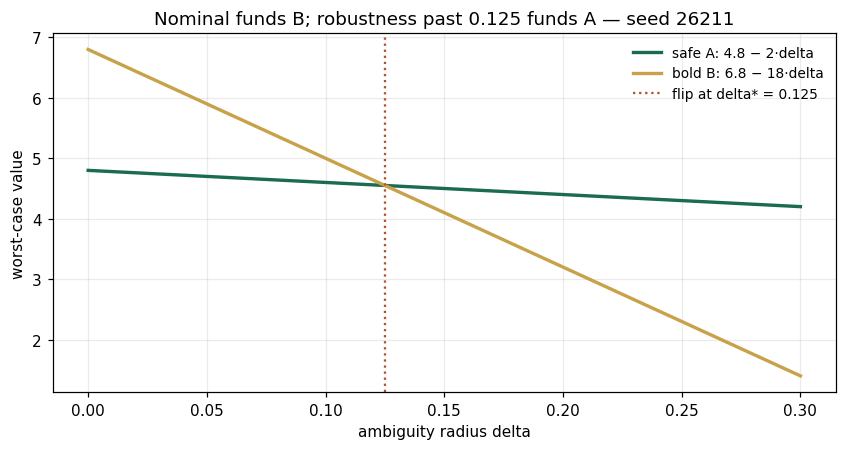

nominal: A 4.8000, B 6.8000   at delta=0.15: A 4.5000, B 4.1000


In [3]:
ds = np.linspace(0, 0.3, 61)
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ds, [wc_mean(ZA, PHAT, d) for d in ds], c="#1B6B52", lw=2.2, label="safe A: 4.8 − 2·delta")
ax.plot(ds, [wc_mean(ZB, PHAT, d) for d in ds], c="#C8A24B", lw=2.2, label="bold B: 6.8 − 18·delta")
ax.axvline(flip_delta(), c="#B0532F", ls=":", lw=1.5, label=f"flip at delta* = {flip_delta():.3f}")
ax.set(xlabel="ambiguity radius delta", ylabel="worst-case value",
       title="Nominal funds B; robustness past 0.125 funds A — seed 26211")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"nominal: A {PHAT@ZA:.4f}, B {PHAT@ZB:.4f}   at delta=0.15: A {wc_mean(ZA,PHAT,0.15):.4f}, B {wc_mean(ZB,PHAT,0.15):.4f}")

## Panel 3 — Data buys boldness
The radius is not a mood — it is calibrated (Data-Driven Enterprise
Optimization, Def.; Statistical Confidence Set, Def.): with $n$ observations,
$\delta_n = 0.55/\sqrt{n}$, shrinking as evidence accumulates (the
Finite-Sample Enterprise Performance Guarantee Theorem's shape). Few samples:
the prudent radius exceeds 0.125 and DRO funds safe A. At **$n = 20$** the
radius drops below the flip and the bold project earns its funding — with a
guarantee attached. Data-Driven Ambiguity Sets Improve Enterprise Adaptability
(Prop.): the same policy machinery, growing bolder exactly as fast as the
evidence justifies.

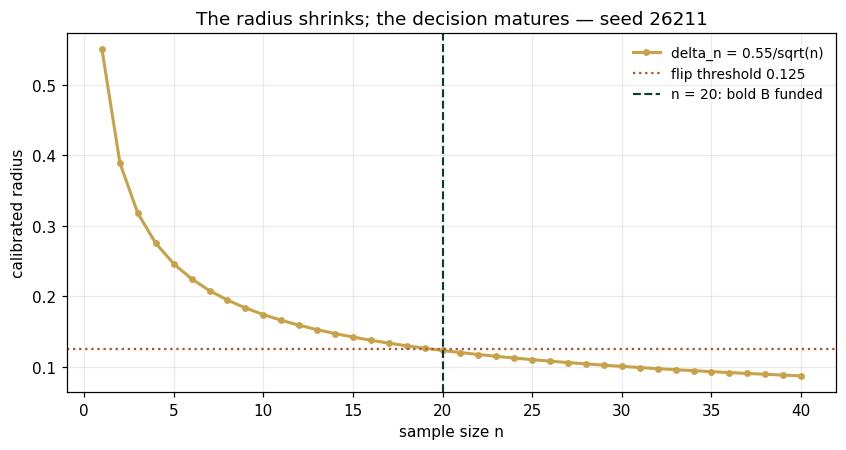

delta(20) = 0.1230   delta(100) = 0.0550   wc_B at n=100: 5.8100
choice(10) = A   choice(20) = B   choice(100) = B


In [4]:
ns = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ns, [delta_n(n) for n in ns], "o-", c="#C8A24B", lw=2, ms=3.5, label="delta_n = 0.55/sqrt(n)")
ax.axhline(flip_delta(), c="#B0532F", ls=":", lw=1.5, label="flip threshold 0.125")
ax.axvline(n_switch(), c="#0B3D2E", ls="--", lw=1.4, label=f"n = {n_switch()}: bold B funded")
ax.set(xlabel="sample size n", ylabel="calibrated radius", title="The radius shrinks; the decision matures — seed 26211")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"delta(20) = {delta_n(20):.4f}   delta(100) = {delta_n(100):.4f}   wc_B at n=100: {wc_mean(ZB,PHAT,delta_n(100)):.4f}")
print(f"choice(10) = {choice(10)}   choice(20) = {choice(20)}   choice(100) = {choice(100)}")

## Validation — agrees with `DCT_V2_Ch11_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"nominal_mean":5.8,"wc_mean_d01":4.4,"wc_slope":14.0,"kink_delta":0.4,
 "wc_mean_d05":-0.8,"nom_A":4.8,"nom_B":6.8,"wc_A_015":4.5,"wc_B_015":4.1,
 "dro_flip_delta":0.125,"delta_n20":0.123,"n_switch":20,"delta_n100":0.055,"wc_B_n100":5.81}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:16s} {ref[k]}")
print("\nAll checkpoints agree — seed 26211.")

PASS  nominal_mean     5.8
PASS  wc_mean_d01      4.4
PASS  wc_slope         14.0
PASS  kink_delta       0.4
PASS  wc_mean_d05      -0.8
PASS  nom_A            4.8
PASS  nom_B            6.8
PASS  wc_A_015         4.5
PASS  wc_B_015         4.1
PASS  dro_flip_delta   0.125
PASS  delta_n20        0.123
PASS  n_switch         20
PASS  delta_n100       0.055
PASS  wc_B_n100        5.81

All checkpoints agree — seed 26211.


**Next**: Exercises 11.5–11.9 (Part C) resize the support and watch the kink structure multiply; AXIOM-11's adversary console lets you fight the worst-case distribution by hand. Chapter 12 turns from one contested objective to several: Pareto. Solutions: IM Vol. II, Ch. 11.